In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

Function to clean data

In [ ]:
def clean_dataframe(df):
    df = df.copy()

    # ---- 1. Drop unnecessary columns (if they exist) ----
    columns_to_drop = ["job_url", "company_url", "benefit", "country", "benifts"]
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

    # ---- 2. Standardize column names ----
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

    # ---- 3. Text cleaning ----
    emoji_pattern = re.compile(r'[\U00010000-\U0010ffff]')

    for col in df.select_dtypes(include="object"):
        df[col] = df[col].apply(
            lambda x: (
                emoji_pattern.sub('', str(x))        # remove emojis
                .replace('\n', ' ')                  # remove newline characters
                .strip()
                .lower()                             # convert to lowercase
            ) if isinstance(x, str) else x
        )

        # remove extra spaces
        df[col] = df[col].str.replace(r"\s+", " ", regex=True)

        # remove special characters except -, /
        df[col] = df[col].str.replace(r"[^\w\s\-\/]", "", regex=True)

    return df

In [21]:
def remove_job_description_duplicates(df):
    df = df.copy()
    
    # Find duplicates (only the repeated ones, not the first occurrence)
    duplicate_count = df.duplicated(subset=["job_description"]).sum()
    print(f"Found {duplicate_count} duplicate rows.")
    
    # Keep first occurrence, remove the rest
    df_clean = df.drop_duplicates(subset=["job_description"], keep="first")
    
    print(f"New dataframe shape: {df_clean.shape}")
    
    return df_clean

In [ ]:
def plot_work_mode_multilingual(df):
    df = df.copy()
    
    text_series = df["job_description"].astype(str).str.lower()
    
    remote_keywords = [
        "remote", "full remote", "work from home",
        "remoto", "trabajo remoto", "en remoto",
        "teletrabajo", "a distancia", "desde casa",
        "home office"
    ]
    
    hybrid_keywords = [
        "hybrid", "hybrid model",
        "híbrido", "hibrido",
        "modalidad híbrida", "modalidad hibrida",
        "modelo híbrido", "modelo hibrido",
        "mixto", "modalidad mixta",
        "combinación presencial y remoto"
    ]
    
    onsite_keywords = [
        "onsite", "on site",
        "presencial", "trabajo presencial",
        "modalidad presencial",
        "en oficina", "en sede"
    ]
    
    def classify_mode(text):
        # Priority: hybrid > remote > onsite
        if any(keyword in text for keyword in hybrid_keywords):
            return "hybrid"
        elif any(keyword in text for keyword in remote_keywords):
            return "remote"
        elif any(keyword in text for keyword in onsite_keywords):
            return "onsite"
        else:
            return "unspecified"
    
    df["work_mode"] = text_series.apply(classify_mode)
    
    counts = df["work_mode"].value_counts()
    
    plt.figure()
    counts.plot(kind="bar")
    plt.xlabel("Work Mode")
    plt.ylabel("Number of Jobs")
    plt.title("Work Mode Distribution (Multilingual)")
    plt.xticks(rotation=0)
    plt.show()
    
    

# EDA data analyst Jonior  

In [34]:
data_scientist_j = pd.read_csv("scientist_jun.csv")


data cleaning: 

In [36]:
clean_dataframe(data_scientist_j)

C:\Users\VORPC\AppData\Local\Temp\ipykernel_35700\6791143.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


,job_title,company_name,location,posted,company_description,job_description
0,científico/a de datos data scientist científic...,quental,barcelona catalonia spain,2 weeks ago,te gustaría participar en un gran proyecto de ...,te gustaría participar en un gran proyecto de ...
1,data scientist,sabadell consumer finance,sant cugat del vallès catalonia spain,1 day ago,qué estamos buscando actualmente nos encontram...,qué estamos buscando actualmente nos encontram...
2,data scientist,linde material handling iberica sa,barcelona catalonia spain,2 weeks ago,linde material handling is among the world lea...,linde material handling is among the world lea...
3,data scientist - 100 teletrabajo,nunegal consulting,spain,1 week ago,tienes experiencia como data scientist te inte...,tienes experiencia como data scientist te inte...
4,machine learning engineer / data engineer,tendam,greater madrid metropolitan area,2 weeks ago,machine learning engineer / data engineer at t...,machine learning engineer / data engineer at t...
...,...,...,...,...,...,...
65,únete a un equipo dinámico envía tu cv,grupo vihotec,murcia región de murcia spain,1 week ago,ubicación varias ubicaciones disponibles jorna...,ubicación varias ubicaciones disponibles jorna...
66,join us comunidad valenciana,the fitzgerald burger company,torrent valencian community spain,NaN,descripción en the fitzgerald nos flipa dar el...,descripción en the fitzgerald nos flipa dar el...
67,entrenador,degood,granada andalusia spain,5 days ago,entrenar bien es sobre todo rodearse bienen de...,entrenar bien es sobre todo rodearse bienen de...
68,mozos de carga y descarga almacén y/o mercado ...,ferrocarrils generalitat valenciana,alicante valencian community spain,3 days ago,requisitospersona joven menor de 30 años e ins...,requisitospersona joven menor de 30 años e ins...


In [37]:
data_scientist_j = remove_job_description_duplicates(data_scientist_j)

Found 8 duplicate rows.
New dataframe shape: (62, 10)


Exploratory Data Analysis

In [46]:
data_scientist_j["job_title"].value_counts().head(15)

job_title
Data Scientist                                                     14
Machine Learning Engineer                                           2
🚀📊 Científico/a de Datos (Data Scientist) (Científic de Dades)      1
Data Scientist - 100% Teletrabajo                                   1
MACHINE LEARNING ENGINEER / DATA ENGINEER                           1
🐍📊 Ingeniero/a Desarrollo Back (Python, Pandas, PySpark)            1
Data Scientist Innovación de Riesgos                                1
Data Scientist Junior                                               1
Junior Machine Learning Engineer                                    1
📍 Data Scientist – ByRatings (Remote-Friendly | Flexible Hours)     1
Data Engineer / Data Scientist                                      1
Data Scientist – Machine Learning                                   1
ML- GenAI Engineer                                                  1
Data Scientist - Advanced Analytics Madrid                          1
Junior Dat

In [39]:
data_scientist_j["location"].value_counts().head(10)

location
Spain                                      15
Madrid, Community of Madrid, Spain         15
Barcelona, Catalonia, Spain                10
Greater Madrid Metropolitan Area            5
Sant Cugat del Vallès, Catalonia, Spain     3
Valencia, Valencian Community, Spain        2
Las Palmas, Canary Islands, Spain           1
Greater Barcelona Metropolitan Area         1
Alcobendas, Community of Madrid, Spain      1
Paterna, Valencian Community, Spain         1
Name: count, dtype: int64

In [40]:
data_scientist_j["posted"].value_counts()

posted
2 weeks ago    16
1 week ago     14
1 day ago       7
5 days ago      4
3 weeks ago     3
4 days ago      3
6 days ago      3
3 days ago      3
Name: count, dtype: int64

In [41]:
data_scientist_j["company_name"].value_counts().head(15)

company_name
Quental                                                   2
Geprom Connecting Industries | Part of Telefónica Tech    2
agap2 Spain                                               2
Voltrac                                                   2
Barcelona Supercomputing Center                           2
Sabadell Consumer Finance                                 1
Linde Material Handling Iberica, SA                       1
Nunegal Consulting                                        1
TENDAM                                                    1
Banco Sabadell                                            1
Red Points                                                1
Insud Pharma                                              1
ByRatings                                                 1
Inetum                                                    1
Fujitsu                                                   1
Name: count, dtype: int64

In [42]:
data_scientist_j["desc_length"] = data_scientist_j["job_description"].str.len()
data_scientist_j["desc_length"].describe()

count      62.000000
mean     3345.177419
std      1678.681660
min       382.000000
25%      2324.000000
50%      3064.500000
75%      4057.500000
max      9418.000000
Name: desc_length, dtype: float64

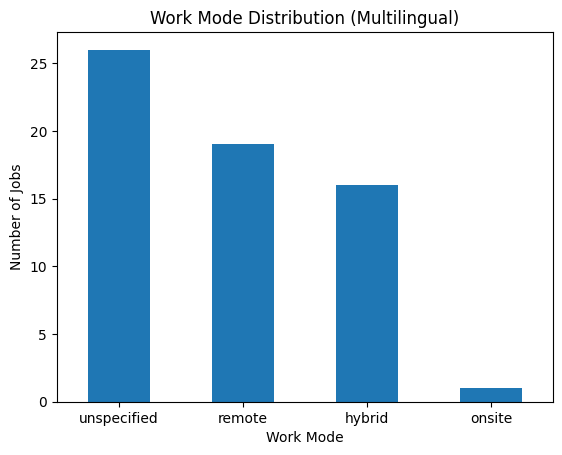

In [53]:
plot_work_mode_multilingual(data_scientist_j)

# EDA Junior Data Analyst 

In [66]:
data_analyst_j = pd.read_csv("analyst_jun.csv")

Clean Data: 

In [67]:
data_analyst_j= clean_dataframe(data_analyst_j)

C:\Users\VORPC\AppData\Local\Temp\ipykernel_35700\6791143.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [61]:
data_analyst_j= remove_job_description_duplicates(data_analyst_j)

Found 5 duplicate rows.
New dataframe shape: (65, 10)


# EDA Senior data scientist 

In [58]:
data_scientist_s = pd.read_csv("scientist_sen.csv")

clean data:

# EDA senior data analyst 

In [59]:
data_analyst_s = pd.read_csv("analyst_sen.csv")

Clean data: 